# Getting started with `chem`

Sanity check that the `chem` kernel and package are wired up correctly.

In [1]:
import chem

chem.__version__

'0.1.0'

## ChEMBL activities for BRAF (UniProt entry name lookup)

`chem.chembl.fetch.download_activities` accepts a ChEMBL target id, a UniProt
accession, or a UniProt entry name (mnemonic) such as `BRAF_HUMAN` — it
resolves the id, calls the ChEMBL REST API directly (no
`chembl_webresource_client`), keeps only records with a pChEMBL value,
filters by molecular weight, and (when `normalize_smiles=True`) standardizes
each compound via the ChEMBL Structure Pipeline and aggregates duplicate
compounds into count/mean/median/std.

In [2]:
import chem.chembl.fetch as cf

n = cf.download_activities(
    "BRAF_HUMAN",
    mw=[250, 650],
    normalize_smiles=True,
    output="braf_activities.tsv",
)
n

[08:25:13] Initializing Normalizer
download_activities(id='BRAF_HUMAN', mw=[250, 650], normalize_smiles=True, output='braf_activities.tsv')


fetching activities for CHEMBL5145:   0%|          | 0/9836 [00:00<?, ?rec/s]

fetching activities for CHEMBL5145:  20%|██        | 2000/9836 [00:08<00:34, 224.57rec/s]

fetching activities for CHEMBL5145:  31%|███       | 3000/9836 [00:17<00:41, 163.61rec/s]

fetching activities for CHEMBL5145:  41%|████      | 4000/9836 [00:27<00:43, 133.08rec/s]

...

fetching activities for CHEMBL5145:  92%|█████████▏| 9000/9836 [01:17<00:07, 104.87rec/s]

fetching activities for CHEMBL5145: 100%|██████████| 9836/9836 [01:27<00:00, 97.08rec/s] 

fetching activities for CHEMBL5145: 100%|██████████| 9836/9836 [01:30<00:00, 108.15rec/s]


wrote 5623 rows to braf_activities.tsv


5623

### Preview the result

In [3]:
import pandas as pd

df = pd.read_csv("braf_activities.tsv", sep="\t")
print(df.size)
df.sort_values("pchembl_mean", ascending=False).head(10)

44984


,parent_chembl_id,target_chembl_id,smiles,mw,n,pchembl_mean,pchembl_median,pchembl_std
4574,CHEMBL5885861,CHEMBL5145,CCNc1nc(-c2cc(NC(=O)c3cccc(S(C)(=O)=O)c3)ccc2C...,495.61,2,10.70,10.70,0.0
161,CHEMBL500659,CHEMBL5145,Cn1cc(-c2ccc3c(c2)CC/C3=N\O)c(-c2ccncc2)n1,304.35,1,10.70,10.70,0.0
155,CHEMBL498344,CHEMBL5145,O/N=C1\CCc2cc(-c3cn([C@@H]4CCC[C@H](O)C4)nc3-c...,388.47,1,10.40,10.40,0.0
5545,CHEMBL5850574,CHEMBL5145,COc1ccc(S(=O)(=O)NCCCNc2nccc(-c3c(-c4ccc(F)c(O...,554.63,1,10.30,10.30,0.0
151,CHEMBL527029,CHEMBL5145,OCCCn1cc(-c2ccc3c(c2)CC/C3=N\O)c(-c2ccncc2)n1,348.41,1,10.30,10.30,0.0
2227,CHEMBL3651664,CHEMBL5145,CCCS(=O)(=O)Nc1cc(Cl)cc(-c2[nH]c(C(C)(C)C)nc2-...,466.97,1,10.10,10.10,0.0
2245,CHEMBL3651683,CHEMBL5145,CS(=O)(=O)Nc1cc(Cl)cc(-c2[nH]c(C3CC3)nc2-c2ccn...,475.94,1,10.10,10.10,0.0
5551,CHEMBL5982580,CHEMBL5145,COc1ccc(S(=O)(=O)NCCCNc2nccc(-c3c(-c4ccc(F)c(O...,538.56,1,10.10,10.10,0.0
154,CHEMBL521562,CHEMBL5145,O/N=C1\CCc2cc(-c3cn([C@@H]4CCC[C@@H](O)C4)nc3-...,388.47,1,10.05,10.05,0.0
2278,CHEMBL3651613,CHEMBL5145,CCS(=O)(=O)Nc1cc(Cl)cc(-c2[nH]c(C(C)(C)C)nc2-c...,550.09,1,10.00,10.00,0.0


### Draw the most potent compound

CHEMBL5885861 pchembl_mean= 10.7 n= 2


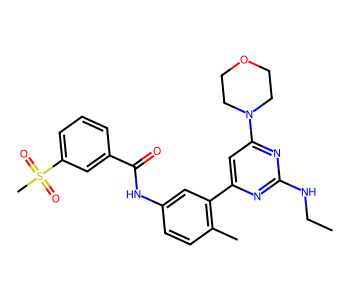

In [4]:
from rdkit import Chem
from rdkit.Chem.Draw import MolToImage

top = df.sort_values("pchembl_mean", ascending=False).iloc[0]
mol = Chem.MolFromSmiles(top["smiles"])
print(top["parent_chembl_id"], "pchembl_mean=", top["pchembl_mean"], "n=", top["n"])
MolToImage(mol, size=(350, 300))